<a href="https://colab.research.google.com/github/HeshanNavindu-7/oilspill-reseach/blob/main/LSTM_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from pathlib import Path
from datetime import datetime, timezone, timedelta
from getpass import getpass

import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

CSV_PATH = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /LSTM Data/oil_spill_expanded_trajectory_dataset_FILLED.csv"

df = pd.read_csv(CSV_PATH)

print("Rows:", len(df))
print("Columns:", len(df.columns))
display(df.head())

Rows: 39
Columns: 46


,scenario_id,repeat_id,image_name,image_path,predicted_mask_path,oil_status,centroid_x,centroid_y,area_pixels,area_ratio,...,swell_u,swell_v,total_drift_u,total_drift_v,east_movement_m,north_movement_m,next_lat,next_lon,metocean_data_source,error
0,1,1,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.233315,-0.531003,0.020612,-0.112002,74.203775,-403.206557,28.841663,-88.358017,stormglass_api,NaN
1,2,2,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.211772,-0.518414,0.014887,-0.110828,53.592743,-398.979043,28.774446,-88.480256,stormglass_api,NaN
2,3,3,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,328.0,257.0,318656.0,0.777969,...,0.117616,-0.382317,-0.037868,-0.096699,-136.326026,-348.115948,28.745595,-88.453729,stormglass_api,NaN
3,4,1,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,229.0,202.0,31264.0,0.076328,...,0.181087,-0.487450,-0.059156,-0.127300,-212.962016,-458.279983,28.864937,-88.492847,stormglass_api,NaN
4,5,2,3_jpg.rf.dcc0e833472d2dbe305cbfb9cd0c2e3a.jpg,/content/drive/MyDrive/Oil Spill/Dataset Creta...,/content/drive/MyDrive/Oil Spill/Dataset Creta...,oil_spill_detected,229.0,202.0,31264.0,0.076328,...,-0.087633,-0.338852,-0.026250,-0.144624,-94.498464,-520.646332,28.655807,-88.473181,sample_filled_after_api_limit,NaN


In [ ]:
feature_columns = [
    "centroid_x",
    "centroid_y",
    "area_pixels",
    "area_ratio",

    "scene_lat",
    "scene_lon",

    "wind_speed",
    "wind_direction",
    "current_speed",
    "current_direction",
    "wave_height",
    "wave_direction",
    "wave_period",
    "swell_height",
    "swell_direction",
    "swell_period",

    "wind_u",
    "wind_v",
    "current_u",
    "current_v",
    "wave_u",
    "wave_v",
    "swell_u",
    "swell_v"
]

target_columns = ["next_lat", "next_lon"]

feature_columns = [col for col in feature_columns if col in df.columns]

model_df = df.copy()
model_df = model_df.dropna(subset=target_columns)
model_df[feature_columns] = model_df[feature_columns].fillna(0)

print("Final rows:", len(model_df))
print("Feature count:", len(feature_columns))
display(model_df[feature_columns + target_columns].head())

Final rows: 39
Feature count: 24


,centroid_x,centroid_y,area_pixels,area_ratio,scene_lat,scene_lon,wind_speed,wind_direction,current_speed,current_direction,...,wind_u,wind_v,current_u,current_v,wave_u,wave_v,swell_u,swell_v,next_lat,next_lon
0,328.0,257.0,318656.0,0.777969,28.845292,-88.358779,2.12,103.88,0.02,111.97,...,-2.058097,0.508565,0.018548,-0.007482,0.269840,-0.444507,0.233315,-0.531003,28.841663,-88.358017
1,328.0,257.0,318656.0,0.777969,28.778037,-88.480806,3.25,114.89,0.05,129.30,...,-2.948132,1.367852,0.038692,-0.031669,0.289744,-0.455684,0.211772,-0.518414,28.774446,-88.480256
2,328.0,257.0,318656.0,0.777969,28.748728,-88.452329,4.26,127.89,0.07,175.06,...,-3.361955,2.616268,0.006028,-0.069740,0.301339,-0.448101,0.117616,-0.382317,28.745595,-88.453729
3,229.0,202.0,31264.0,0.076328,28.869062,-88.490658,4.05,133.04,0.10,200.67,...,-2.960053,2.764161,-0.035298,-0.093563,0.312235,-0.452780,0.181087,-0.487450,28.864937,-88.492847
4,229.0,202.0,31264.0,0.076328,28.660493,-88.472212,4.35,156.50,0.11,172.00,...,-1.734558,3.989211,0.015309,-0.108929,0.128276,-0.809904,-0.087633,-0.338852,28.655807,-88.473181


In [ ]:
from sklearn.preprocessing import MinMaxScaler

X = model_df[feature_columns].values
y = model_df[target_columns].values

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

print("X shape:", X_scaled.shape)
print("y shape:", y_scaled.shape)

X shape: (39, 24)
y shape: (39, 2)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["image_name"].values

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X_scaled, y_scaled, groups=groups))

X_train = X_scaled[train_idx]
X_test = X_scaled[test_idx]

y_train = y_scaled[train_idx]
y_test = y_scaled[test_idx]

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train images:", train_df["image_name"].nunique())
print("Test images:", test_df["image_name"].nunique())

Train rows: 27
Test rows: 12
Train images: 9
Test images: 4


In [ ]:
# LSTM input shape should be: samples, timesteps, features
# Since each row is one scenario, use timestep = 1

X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("X_train_lstm shape:", X_train_lstm.shape)
print("X_test_lstm shape:", X_test_lstm.shape)

X_train_lstm shape: (27, 1, 24)
X_test_lstm shape: (12, 1, 24)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

lstm_model = Sequential([
    LSTM(
        64,
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]),
        return_sequences=False
    ),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(2)
])

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,426 (99.32 KB)

 Trainable params: 25,426 (99.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step - loss: 0.2672 - mae: 0.4058 - val_loss: 0.3741 - val_mae: 0.5581
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.2276 - mae: 0.3693 - val_loss: 0.3229 - val_mae: 0.5078
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2006 - mae: 0.3468 - val_loss: 0.2827 - val_mae: 0.4645
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1793 - mae: 0.3252 - val_loss: 0.2435 - val_mae: 0.4248
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1538 - mae: 0.3018 - val_loss: 0.2054 - val_mae: 0.3848
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.1413 - mae: 0.2962 - val_loss: 0.1695 - val_mae: 0.3427
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1161 - mae: 0.2664 - val_loss: 0.1361 - val_mae: 0.3070
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0967 - mae: 0.2516 - val_loss: 0.1074 - val_mae: 0.2718
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0901 - mae:

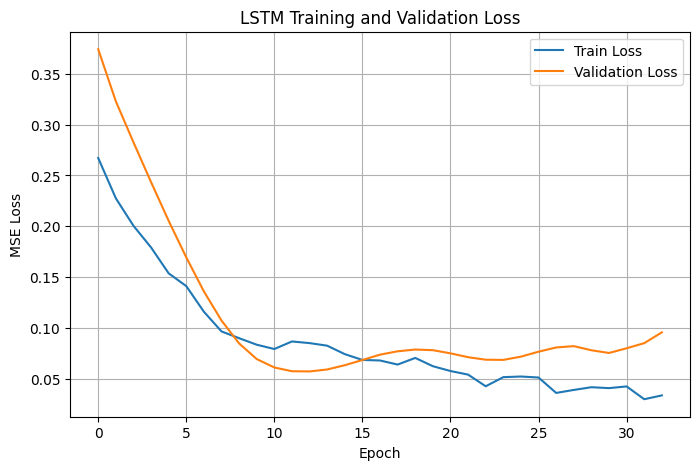

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

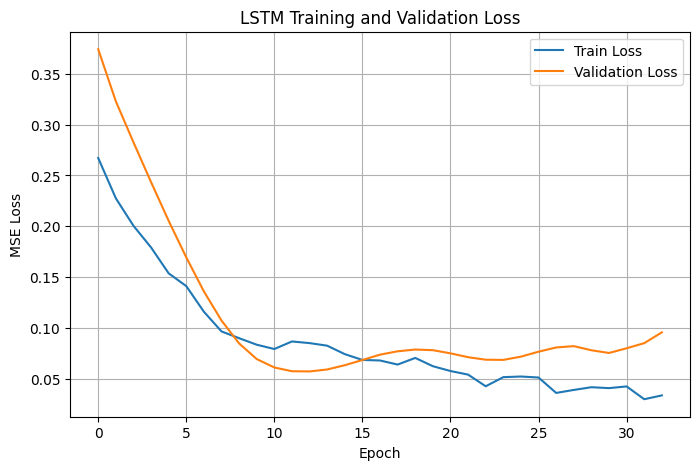

Saved: /content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/lstm_training_loss.png


In [ ]:
LSTM_LOSS_PLOT = "/content/drive/MyDrive/Oil Spill/Dataset Cretaion /Trajectory_Dataset/lstm_training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(LSTM_LOSS_PLOT, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", LSTM_LOSS_PLOT)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

pred_scaled = lstm_model.predict(X_test_lstm)

# Convert back to actual latitude/longitude scale
pred_lstm = scaler_y.inverse_transform(pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

lstm_mae = mean_absolute_error(y_test_actual, pred_lstm)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, pred_lstm))
lstm_r2 = r2_score(y_test_actual, pred_lstm)

print("LSTM Trajectory Model Evaluation")
print("MAE :", lstm_mae)
print("RMSE:", lstm_rmse)
print("R2  :", lstm_r2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step
LSTM Trajectory Model Evaluation
MAE : 0.07769299996922241
RMSE: 0.08915978628439662
R2  : -0.42511745428887193


In [ ]:
import math

def haversine_distance_m(lat1, lon1, lat2, lon2):
    R = 6371000

    lat1 = math.radians(lat1)
    lon1 = math.radians(lon1)
    lat2 = math.radians(lat2)
    lon2 = math.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        math.sin(dlat / 2) ** 2
        + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    )

    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))

    return R * c


lstm_distance_errors = []

for actual, predicted in zip(y_test_actual, pred_lstm):
    actual_lat, actual_lon = actual
    pred_lat, pred_lon = predicted

    dist_error = haversine_distance_m(
        actual_lat,
        actual_lon,
        pred_lat,
        pred_lon
    )

    lstm_distance_errors.append(dist_error)

lstm_distance_errors = np.array(lstm_distance_errors)

print("LSTM Distance Error Results")
print("Mean distance error:", lstm_distance_errors.mean(), "meters")
print("RMSE distance error:", np.sqrt(np.mean(lstm_distance_errors ** 2)), "meters")
print("Min distance error:", lstm_distance_errors.min(), "meters")
print("Max distance error:", lstm_distance_errors.max(), "meters")

LSTM Distance Error Results
Mean distance error: 13022.180365000699 meters
RMSE distance error: 13569.838042680436 meters
Min distance error: 8322.809504900346 meters
Max distance error: 19478.68977522479 meters


In [ ]:
lstm_comparison_df = test_df[[
    "scenario_id",
    "image_name",
    "scene_lat",
    "scene_lon",
    "next_lat",
    "next_lon"
]].copy()

lstm_comparison_df["lstm_pred_next_lat"] = pred_lstm[:, 0]
lstm_comparison_df["lstm_pred_next_lon"] = pred_lstm[:, 1]

lstm_comparison_df["lstm_lat_error"] = abs(
    lstm_comparison_df["next_lat"] - lstm_comparison_df["lstm_pred_next_lat"]
)

lstm_comparison_df["lstm_lon_error"] = abs(
    lstm_comparison_df["next_lon"] - lstm_comparison_df["lstm_pred_next_lon"]
)

lstm_comparison_df["lstm_distance_error_m"] = lstm_distance_errors

display(lstm_comparison_df)

,scenario_id,image_name,scene_lat,scene_lon,next_lat,next_lon,lstm_pred_next_lat,lstm_pred_next_lon,lstm_lat_error,lstm_lon_error,lstm_distance_error_m
0,1,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.845292,-88.358779,28.841663,-88.358017,28.676117,-88.397942,0.165546,0.039925,18814.804003
1,2,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.778037,-88.480806,28.774446,-88.480256,28.677763,-88.408073,0.096683,0.072183,12849.818183
2,3,2_jpg.rf.6cf3e30a41dcc614556c92dee4b821dd.jpg,28.748728,-88.452329,28.745595,-88.453729,28.678724,-88.415390,0.066871,0.038339,8322.809505
24,25,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.786953,-88.332608,28.785734,-88.334192,28.685966,-88.375748,0.099767,0.041556,11810.354678
25,26,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.847316,-88.245393,28.846415,-88.247250,28.700884,-88.352829,0.145532,0.105579,19177.044178
26,27,Defense.gov_photo_essay_100506-N-6436W-023.jpg,28.809818,-88.334041,28.811377,-88.332897,28.707064,-88.358871,0.104314,0.025974,11872.276024
27,28,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.648224,-88.452546,28.651527,-88.455308,28.708996,-88.346817,0.057469,0.108491,12363.153568
28,29,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.792011,-88.252219,28.795756,-88.254411,28.728991,-88.311531,0.066766,0.057120,9279.881800
29,30,Skimming_Oil_in_Gulf_of_Mexico.jpg,28.875962,-88.277603,28.879310,-88.280643,28.710712,-88.334908,0.168598,0.054265,19478.689775
33,34,_____thumb_fed_photo_jpg.rf.9aeb1f79f20f1885c9...,28.628826,-88.363176,28.631590,-88.365534,28.709692,-88.378082,0.078102,0.012549,8770.405889


In [ ]:
rf_mae = 0.03859745776499872
rf_rmse = 0.05135330872935758
rf_r2 = 0.52163067044691
rf_mean_distance_error = 6657.078951318603
rf_rmse_distance_error = 7952.814003052021

model_comparison_df = pd.DataFrame([
    {
        "Model": "Random Forest Baseline",
        "MAE_degrees": rf_mae,
        "RMSE_degrees": rf_rmse,
        "R2": rf_r2,
        "Mean_Distance_Error_km": rf_mean_distance_error / 1000,
        "RMSE_Distance_Error_km": rf_rmse_distance_error / 1000
    },
    {
        "Model": "LSTM Prototype",
        "MAE_degrees": lstm_mae,
        "RMSE_degrees": lstm_rmse,
        "R2": lstm_r2,
        "Mean_Distance_Error_km": lstm_distance_errors.mean() / 1000,
        "RMSE_Distance_Error_km": np.sqrt(np.mean(lstm_distance_errors ** 2)) / 1000
    }
])

display(model_comparison_df)

,Model,MAE_degrees,RMSE_degrees,R2,Mean_Distance_Error_km,RMSE_Distance_Error_km
0,Random Forest Baseline,0.038597,0.051353,0.521631,6.657079,7.952814
1,LSTM Prototype,0.077693,0.089160,-0.425117,13.022180,13.569838
